# Proteome remodeling during human erythropoiesis

This notebook demonstrates a comprehensive protein-level analysis workflow using ProteoPy.
To this aim we selected a human erythropoiesis DIA dataset by Karayel et al. (2020):

> Karayel Ö, Xu P, Bludau I, Velan Bhoopalan S, Yao Y, Ana Rita FC, Santos A, Schulman BA, Alpi AF, Weiss MJ, and Mann M. **Integrative proteomics reveals principles of dynamic phosphosignaling networks in human erythropoiesis.** *Molecular Systems Biology*, 16(12):MSB20209813, 2020. [doi:10.15252/msb.20209813](https://doi.org/10.15252/msb.20209813)

The authors profiled the proteome across five stages of *in vitro* erythropoiesis from CD34⁺ hematopoietic stem/progenitor cells (HSPCs) — progenitors, proerythroblasts and early basophilic erythroblasts (ProE&EBaso), late basophilic erythroblasts (LBaso), polychromatic erythroblasts (Poly), and orthochromatic erythroblasts (Ortho) — using DIA-based mass spectrometry with four biological replicates per stage. They quantified ~7,400 proteins, demonstrating high reproducibility within stages and stage-specific proteome remodeling driven by drastic transitions at the progenitor-to-ProE&EBaso and Poly-to-Ortho boundaries. Hierarchical clustering revealed six distinct co-expression profiles across differentiation.

Here, we show how ProteoPy can be used to perform typical protein-level analysis steps: quality control, normalization, dimensionality reduction, differential abundance testing.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import rc_context

import proteopy as pr
from proteopy.utils.anndata import is_proteodata

cwd = Path(".").resolve()
(cwd / "data").mkdir(parents=True, exist_ok=True)

## Reading in the data

The Karayel et al. (2020) dataset contains protein-level DIA-MS intensities from five erythroid differentiation stages of CD34⁺ HSPCs. ProteoPy provides a built-in download function (`pr.download.karayel_2020()`) that fetches the dataset from the PRIDE archive (PXD017276), processes it, and saves it as three separate files:

- **Intensities** — long-format table with columns `sample_id`, `protein_id`, and `intensity` (one row per measurement)
- **Sample annotation** — maps each `sample_id` to its `cell_type` and `replicate`
- **Protein annotation** — maps each `protein_id` to its `gene_id`

This separation into three files mirrors a common data delivery format in proteomics. The files are then read into an AnnData object using `pr.read.long()`.

In [2]:
intensities_path = (
    "data/karayel-2020_ms-proteomics"
    "_human-erythropoiesis_intensities.tsv"
)
sample_annotation_path = (
    "data/karayel-2020_ms-proteomics"
    "_human-erythropoiesis_sample-annotation.tsv"
)
var_annotation_path = (
    "data/karayel-2020_ms-proteomics"
    "_human-erythropoiesis_protein-annotation.tsv"
)

pr.download.karayel_2020(
    intensities_path=intensities_path,
    sample_annotation_path=sample_annotation_path,
    var_annotation_path=var_annotation_path,
    force=True,
)

A quick look at the first rows of each file confirms the expected structure:

In [3]:
!head -n5 {intensities_path}

sample_id	protein_id	intensity
LBaso_rep1	A0A024QZ33;Q9H0G5	15084.2626953125
LBaso_rep2	A0A024QZ33;Q9H0G5	15442.2646484375
LBaso_rep3	A0A024QZ33;Q9H0G5	13992.021484375
LBaso_rep4	A0A024QZ33;Q9H0G5	18426.5390625


In [4]:
!head -n5 {sample_annotation_path}

sample_id	cell_type	replicate
LBaso_rep1	LBaso	rep1
LBaso_rep2	LBaso	rep2
LBaso_rep3	LBaso	rep3
LBaso_rep4	LBaso	rep4


In [5]:
!head -n5 {var_annotation_path}

protein_id	gene_id
A0A024QZ33;Q9H0G5	NSRP1
A0A024QZB8;A0A0A0MRC7;A0A0D9SFH9;A0A1B0GV71;A0A1B0GW34;A0A1B0GWD3;H3BR00;Q13286;Q13286-2;Q13286-3;Q13286-4;Q13286-5;Q9UBD8	CLN3;CLN3;CLN3;CLN3;CLN3;;CLN3;CLN3;CLN3;CLN3;CLN3;CLN3;CLN3
A0A024R0Y4;O75478	TADA2A
A0A024R216;Q9Y3E1	HDGFRP3;HDGFL3


With the three files on disk, `pr.read.long()` reads the long-format intensities, pivots them into a dense matrix, and merges the sample and protein annotations into a single AnnData object. Setting `fill_na=0` replaces any missing intensity values with zero.

In [6]:
adata = pr.read.long(
    intensities=intensities_path,
    sample_annotation=sample_annotation_path,
    var_annotation=var_annotation_path,
    level="protein",
    fill_na=0,
)

adata

AnnData object with n_obs × n_vars = 20 × 7758
    obs: 'sample_id', 'cell_type', 'replicate'
    var: 'protein_id', 'gene_id'

In [7]:
print("Is proteodata: ", is_proteodata(adata))

Is proteodata:  (True, 'protein')


Define consistent color schemes for the differentiation stages and replicates used throughout the notebook.

In [8]:
# Cell types
adata.uns["colors_cell_type"] = {
    "LBaso": "#D91C5C",
    "Ortho": "#F6922F",
    "Poly": "#262261",
    "ProE&EBaso": "#1B75BB",
    "Progenitor": "#D6DE3B",
}

diff_order = ["Progenitor", "ProE&EBaso", "LBaso", "Poly", "Ortho"]

# Replicates
n_reps = adata.obs["replicate"].nunique()
cmap = mpl.colormaps["tab10"]
adata.uns["colors_replicate"] = cmap(range(n_reps)).tolist()

rep_order = sorted(adata.obs["replicate"].unique().tolist())

## Quality control and preprocessing

By study design, the dataset consists of 5 differentiation stages with 4 biological replicates each (20 samples). We apply standard QC steps: completeness-based filtering and visual inspection of various statistics such as the number of detected protein groups, as well as the intensity and coefficient of variation distributions.

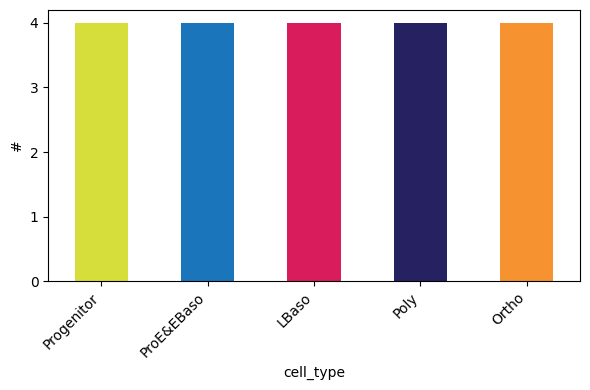

In [9]:
pr.pl.n_samples_per_category(
    adata,
    category_key="cell_type",
    order=diff_order,
    color_scheme=adata.uns["colors_cell_type"],
)

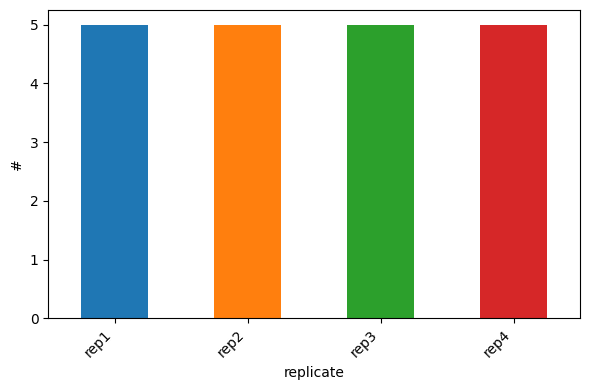

In [10]:
pr.pl.n_samples_per_category(
    adata,
    category_key="replicate",
    color_scheme=adata.uns["colors_replicate"],
    order=rep_order,
)

### Abundance rank plot

Abundance rank plots show the dynamic range and ranking of marker proteins across stages. Intensity signals span five (Progenitor) to seven (Ortho) orders of magnitude. Haemoglobin subunits increase by approximately three orders of magnitude from Progenitor to Ortho and rank among the most abundant proteins in later stages.

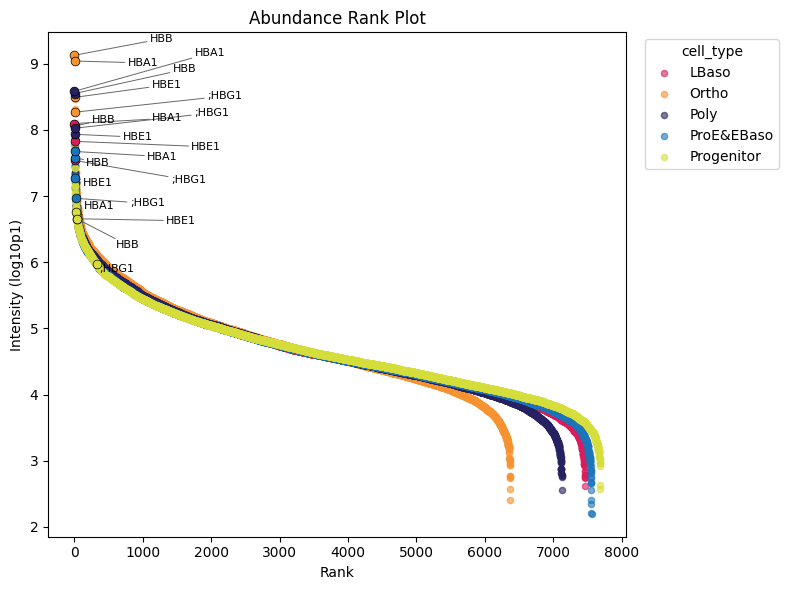

In [11]:
haemoglobin = {
    "P68871": "HBB",
    "P69905": "HBA1",
    "P02100": "HBE1",
    "A0A2R8Y7X9;P69891": "HBG1",
}

pr.pl.abundance_rank(
    adata,
    color="cell_type",
    log_transform=10,
    zero_to_na=True,
    color_scheme=adata.uns["colors_cell_type"],
    summary_method="median",
    highlight_vars=list(haemoglobin.keys()),
    var_labels_key="gene_id",
)

### Completeness filtering

Proteins are retained if they are detected in all replicates of at least one differentiation stage, ensuring that only consistently quantified proteins remain.

In [13]:
pr.pp.filter_var_completeness(
    adata,
    min_fraction=1,
    group_by="cell_type",
    zero_to_na=True,
)

279 var removed


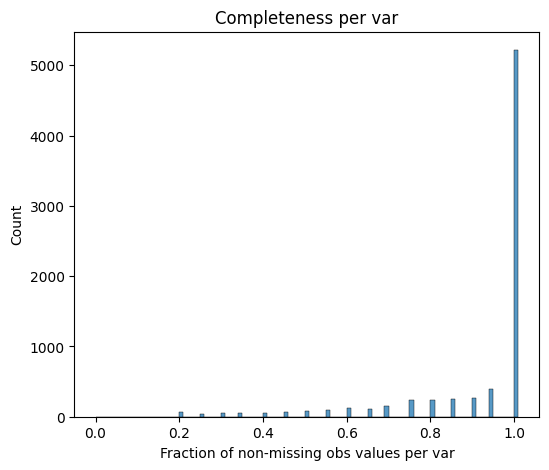

<Axes: title={'center': 'Completeness per var'}, xlabel='Fraction of non-missing obs values per var', ylabel='Count'>

In [ ]:
pr.pl.completeness_per_var(adata, zero_to_na=True)

In [16]:
print(
    f"{adata.n_vars} protein groups remain after "
    f"filtering for group-wise completeness"
)

7479 protein groups remain after filtering for group-wise completeness


### Detected proteins per sample

After filtering, 7,479 protein groups remain. The per-sample detected proteins plot shows a decrease along the differentiation trajectory (left -> right order).

Global:
 mean_count  std_count  median_count  min_count  max_count  mean_pct  std_pct  median_pct  min_pct  max_pct
     6857.7      582.9        7095.0       5484       7403      91.7      7.8        94.9     73.3     99.0

Per cell_type:
 cell_type  mean_count  std_count  median_count  min_count  max_count  mean_pct  std_pct  median_pct  min_pct  max_pct
     LBaso      7097.8      129.9        7095.0       6981       7220      94.9      1.7        94.9     93.3     96.5
     Ortho      5851.0      251.0        5934.0       5484       6052      78.2      3.4        79.3     73.3     80.9
      Poly      6712.2      224.6        6755.5       6407       6931      89.7      3.0        90.3     85.7     92.7
ProE&EBaso      7271.2       43.4        7269.5       7220       7326      97.2      0.6        97.2     96.5     98.0
Progenitor      7356.2       65.6        7381.5       7259       7403      98.4      0.9        98.7     97.1     99.0


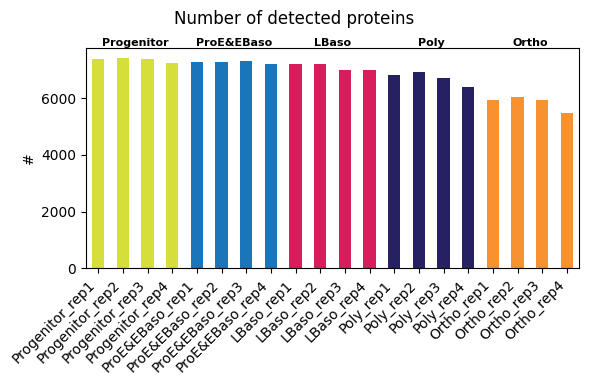

<Axes: ylabel='#'>

In [17]:
pr.pl.n_proteins_per_sample(
    adata,
    zero_to_na=True,
    order_by="cell_type",
    order=diff_order,
    color_scheme=adata.uns["colors_cell_type"],
    xlabel_rotation=45,
    print_stats=True,
)

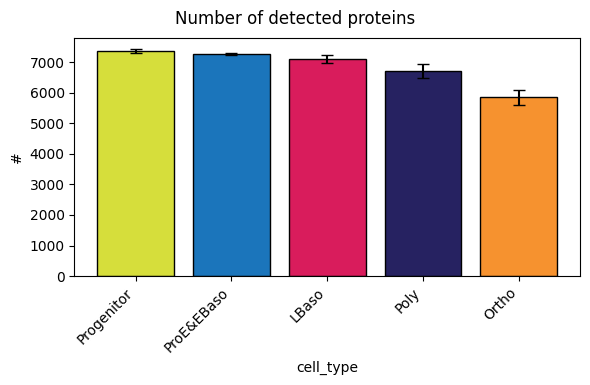

<Axes: xlabel='cell_type', ylabel='#'>

In [18]:
# Group samples by cell type
pr.pl.n_proteins_per_sample(
    adata,
    zero_to_na=True,
    group_by="cell_type",
    order=diff_order,
    color_scheme=adata.uns["colors_cell_type"],
    xlabel_rotation=45,
)

### Coefficient of variation

Intra-stage coefficients of variation (CVs) confirm high technical reproducibility across replicates.

Global CV Summary:
 Count    Min   Max  Median   Mean    Std
 34054 0.0021 1.971  0.1099 0.1725 0.1887

Per-Group CV Summary:
            Count     Min     Max  Median    Mean     Std
Group                                                    
Progenitor   7366  0.0051  1.8955  0.1219  0.1899  0.2054
ProE&EBaso   7261  0.0038  1.8931  0.0774  0.1336  0.1674
LBaso        7058  0.0046  1.8879  0.1147  0.1736  0.1842
Poly         6646  0.0047  1.9710  0.1292  0.1878  0.1887
Ortho        5723  0.0021  1.9081  0.1176  0.1805  0.1904

Global Threshold Summary (hline=0.2):
 Count below  Percentage below
       25308           74.3173

Per-Group Threshold Summary (hline=0.2):
            Count below  Percentage below
Group                                    
Progenitor       5151.0           69.9294
ProE&EBaso       6082.0           83.7626
LBaso            5322.0           75.4038
Poly             4642.0           69.8465
Ortho            4111.0           71.8330



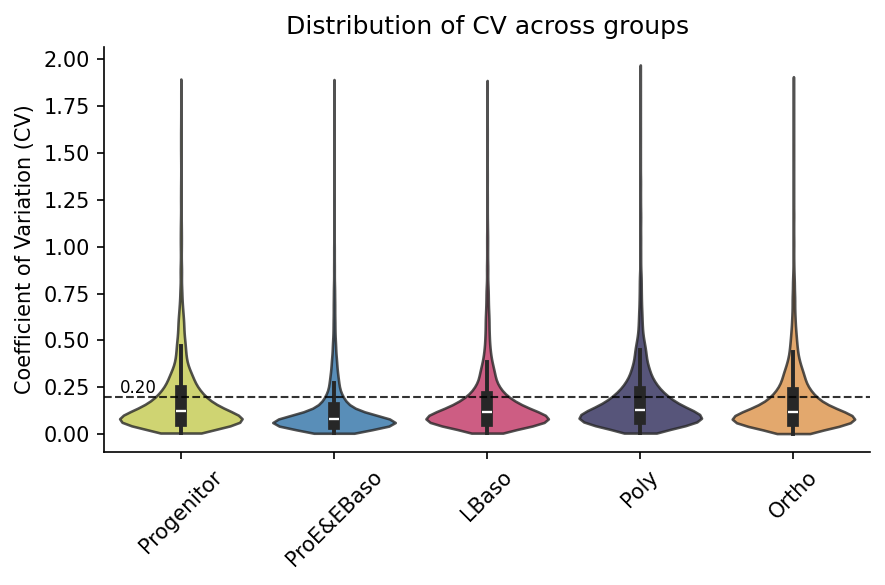

In [19]:
pr.pl.cv_by_group(
    adata,
    group_by="cell_type",
    min_samples=3,
    zero_to_na=True,
    color_scheme=adata.uns["colors_cell_type"],
    figsize=(6, 4),
    xlabel_rotation=45,
    order=diff_order,
    hline=0.2,
    print_stats=True,
)

## Data transformation

We apply log₂ transformation, median normalization, and down-shift imputation of missing values to prepare the data for downstream analysis.

In [20]:
# Convert zeros to NaN and log2 transform
adata.layers["raw"] = adata.X.copy()
adata.X[adata.X == 0] = np.nan
adata.X = np.log2(adata.X)

### Median normalization

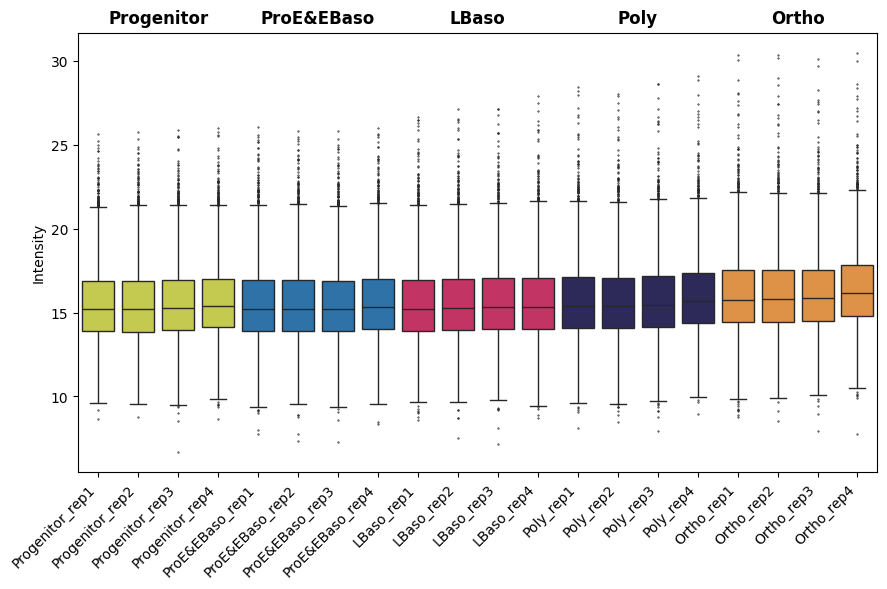

<Axes: ylabel='Intensity'>

In [21]:
pr.pl.intensity_box_per_sample(
    adata,
    order_by="cell_type",
    order=diff_order,
    zero_to_na=True,
    color_scheme=adata.uns["colors_cell_type"],
    xlabel_rotation=45,
    figsize=(9, 6),
)

In [22]:
pr.pp.normalize_median(adata, log_space=True)

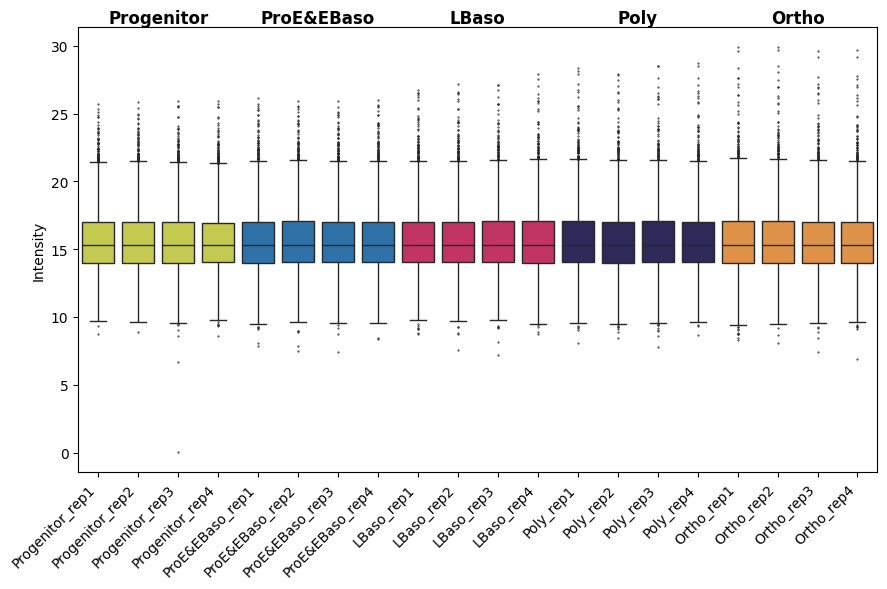

<Axes: ylabel='Intensity'>

In [23]:
# After normalization: median values across samples are the same
pr.pl.intensity_box_per_sample(
    adata,
    order_by="cell_type",
    order=diff_order,
    zero_to_na=True,
    color_scheme=adata.uns["colors_cell_type"],
    xlabel_rotation=45,
    figsize=(9, 6),
)

### Down-shift imputation

Missing values are imputed using a downshifted Gaussian distribution, following the approach popularized by Perseus (Tyanova et al., 2016), where random values are drawn from a normal distribution shifted toward lower intensities. The approach assumes that missing values arise from low-abundance proteins below the detection limit (missing not at random, MNAR).

In [24]:
pr.pp.impute_downshift(
    adata,
    downshift=1.8,
    width=0.3,
    zero_to_na=True,
    random_state=123,
    verbose=True,
)

Measured: 137,154 values (91.7%)
Imputed: 12,426 values (8.3%)


Intensity distributions with imputed values highlighted confirm that imputed values form a distinct low-intensity shoulder:

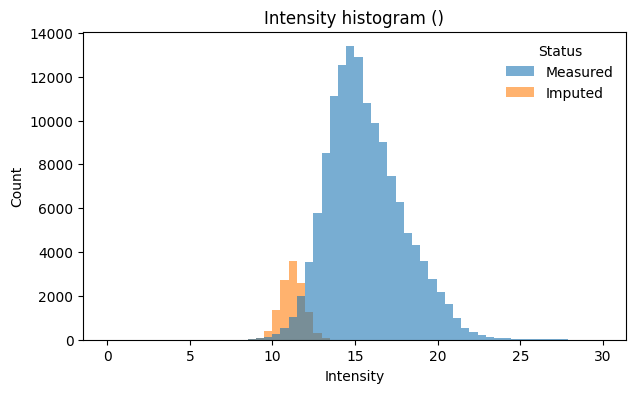

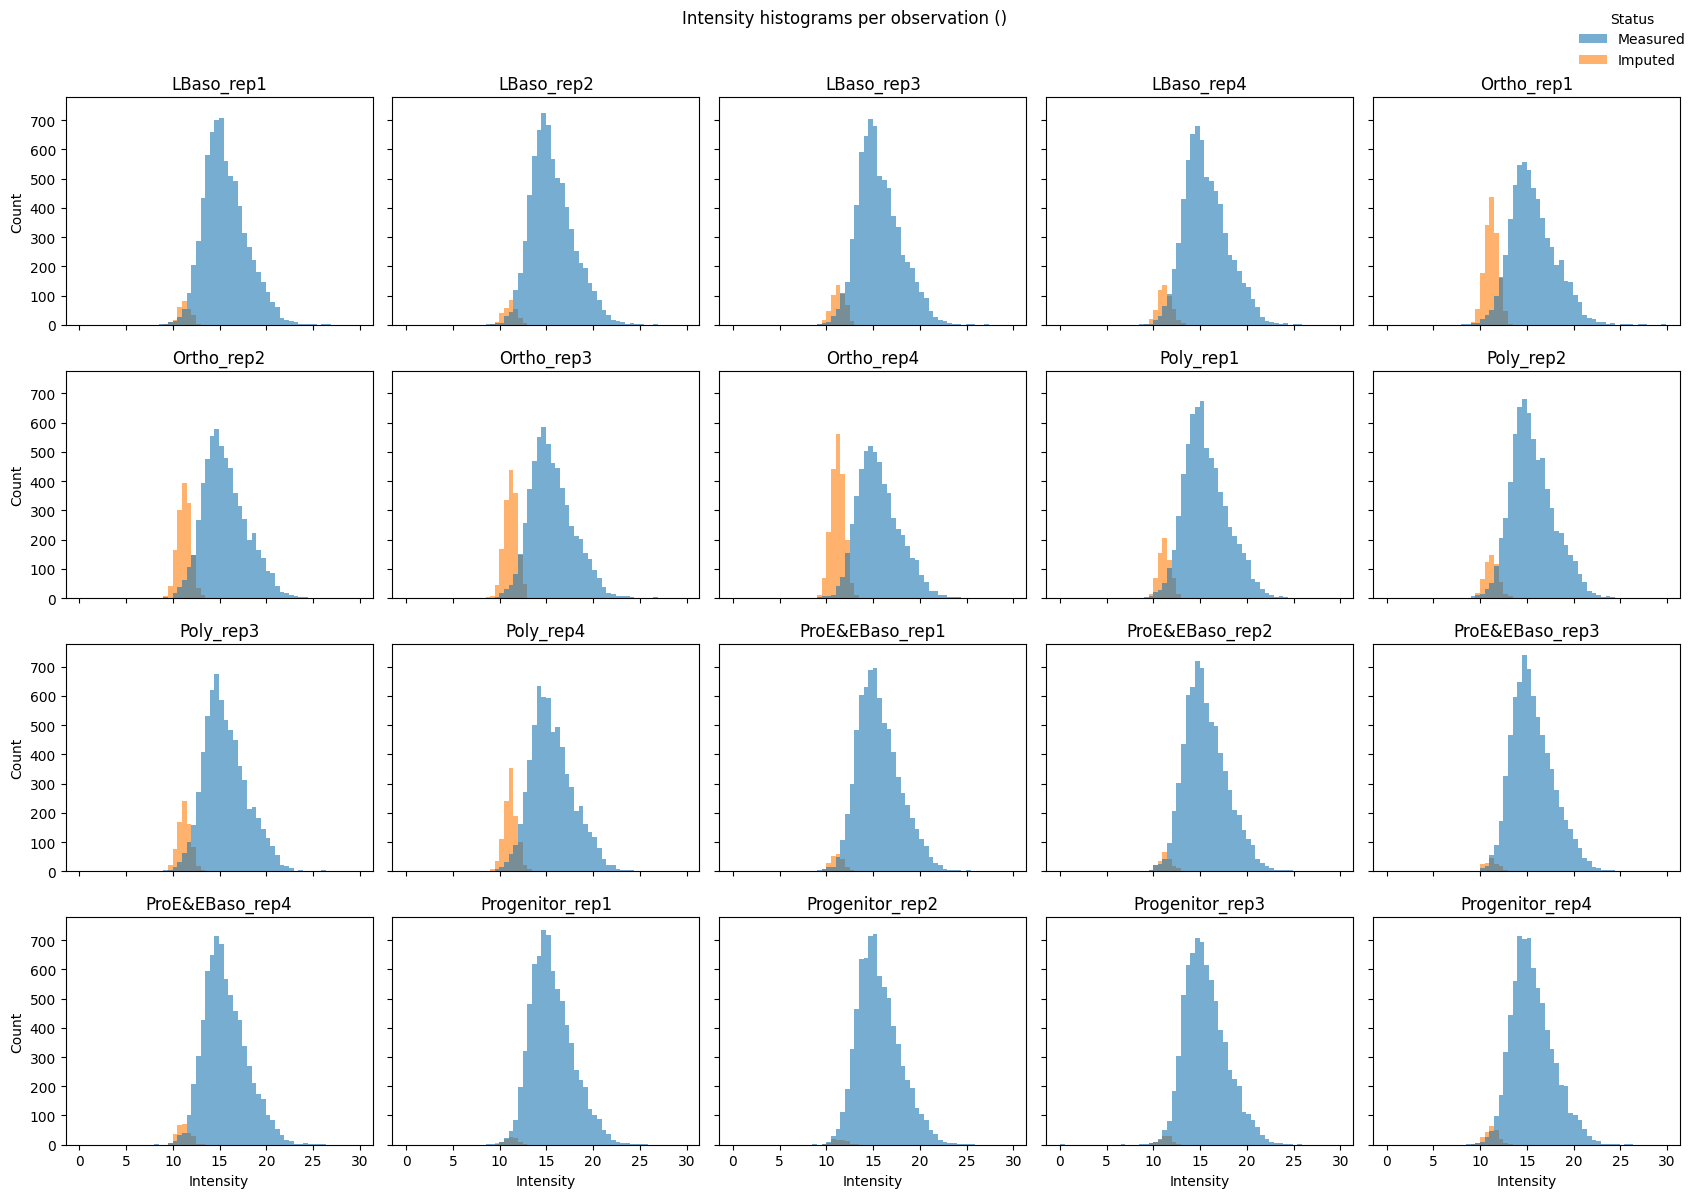

In [25]:
# Combined histogram across all samples
pr.pl.intensity_hist(
    adata,
    color_imputed=True,
    density=False,
)

# Per-sample histograms (small multiples)
pr.pl.intensity_hist(
    adata,
    color_imputed=True,
    per_obs=True,
    ncols=5,
    legend_loc="upper right",
    density=False,
    figsize=(17, 12),
)

## Exploratory data analysis

### Sample correlation matrix

High intra-stage (Pearson *r* > 0.94) and lower inter-stage Pearson correlations confirm that protein abundances are primarily driven by differentiation stage.

Sample correlation summary (off-diagonal, pearson):
     min      max     mean   median      std
0.772086 0.976173 0.901526 0.909919 0.049865

Per-sample mean correlation:
      sample_id  mean_corr
     Ortho_rep4   0.864798
     Ortho_rep3   0.885271
     Ortho_rep1   0.872628
     Ortho_rep2   0.881339
Progenitor_rep4   0.856958
Progenitor_rep3   0.866849
Progenitor_rep1   0.891815
Progenitor_rep2   0.898941
     LBaso_rep1   0.924209
     LBaso_rep2   0.925118
ProE&EBaso_rep4   0.918244
ProE&EBaso_rep1   0.917999
ProE&EBaso_rep2   0.920335
ProE&EBaso_rep3   0.919495
      Poly_rep3   0.911729
      Poly_rep4   0.901124
      Poly_rep1   0.912838
     LBaso_rep4   0.921740
     LBaso_rep3   0.921465
      Poly_rep2   0.917615

Per-group mean correlation:
     group  mean_within  mean_between
     LBaso     0.955621      0.917042
     Ortho     0.941910      0.863653
      Poly     0.950539      0.903380
ProE&EBaso     0.968593      0.909723
Progenitor     0.954879      0.864346



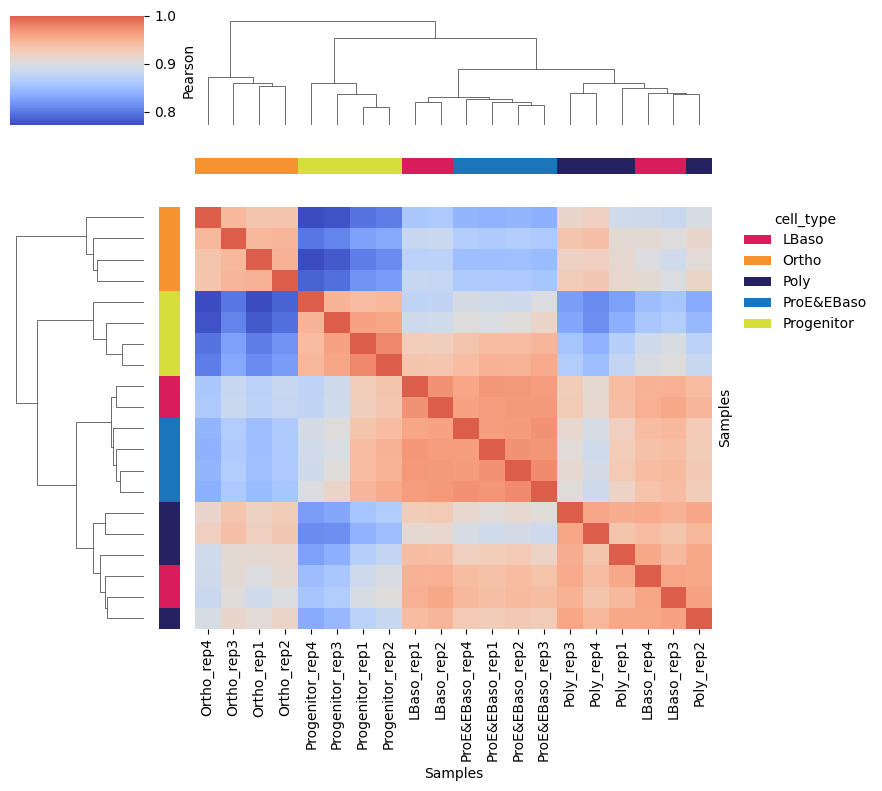

In [26]:
pr.pl.sample_correlation_matrix(
    adata,
    margin_color="cell_type",
    color_scheme=adata.uns["colors_cell_type"],
    xticklabels=True,
    figsize=(9, 8),
    print_stats=True,
)

PCA and UMAP further confirm that differentiation stage is the dominant source of variation.

### PCA

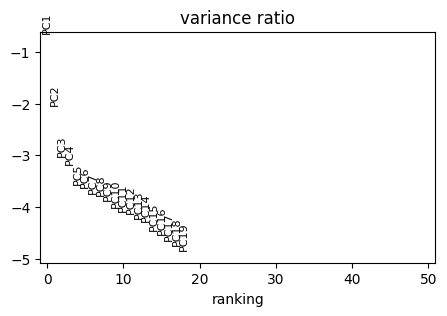

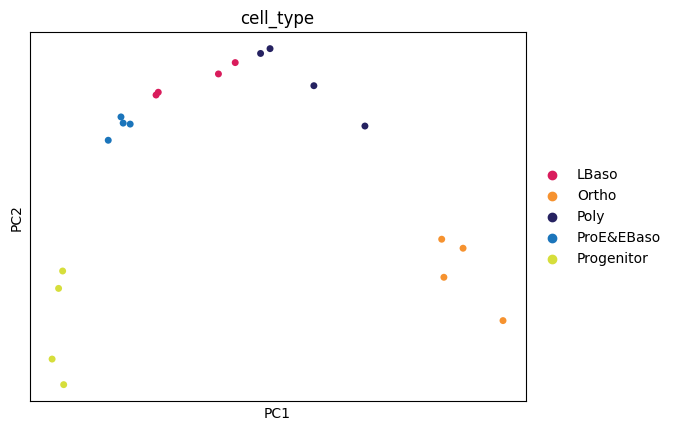

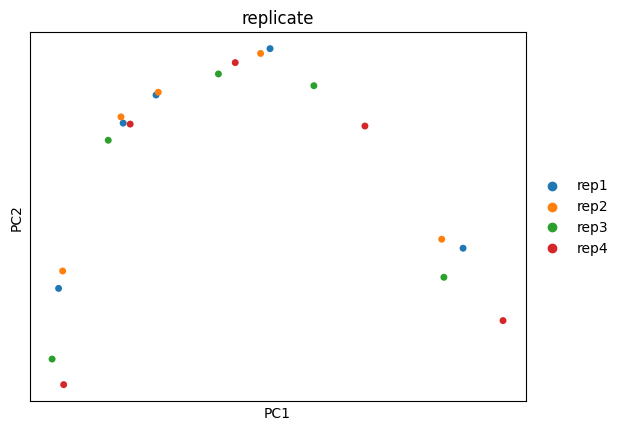

In [27]:
sc.tl.pca(adata)
with rc_context({"figure.figsize": (5, 3)}):
    sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

sc.pl.pca(
    adata,
    color="cell_type",
    dimensions=(0, 1),
    ncols=2,
    size=100,
    palette=adata.uns["colors_cell_type"],
)

sc.pl.pca(
    adata,
    color="replicate",
    dimensions=(0, 1),
    ncols=2,
    size=100,
    palette=adata.uns["colors_replicate"],
)

### UMAP

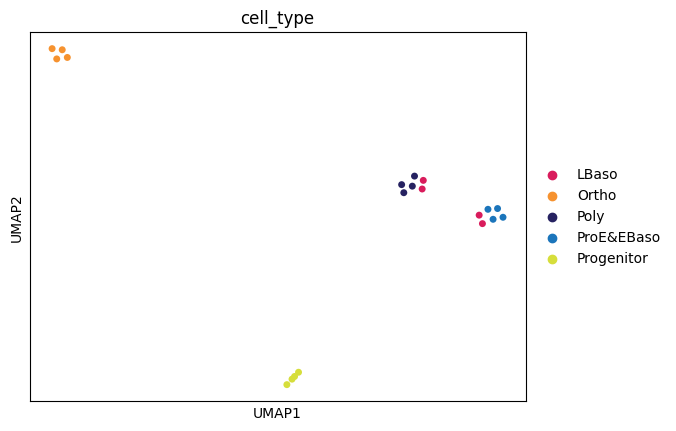

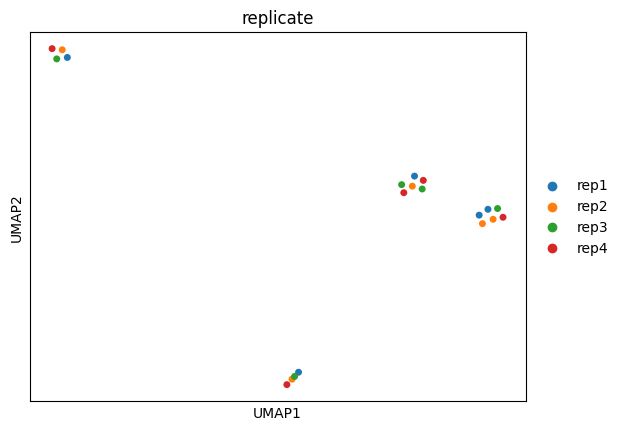

In [28]:
sc.pp.neighbors(adata, n_neighbors=3)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="cell_type",
    size=100,
    palette=adata.uns["colors_cell_type"],
)

sc.pl.umap(
    adata,
    color="replicate",
    size=100,
    palette=adata.uns["colors_replicate"],
)

## Differential protein abundance

Pairwise comparisons of each stage against the progenitor stage reveal cumulative proteome remodeling. The later maturation stages (Poly, Ortho) show a larger number of differentially abundant proteins, reflecting the progressive divergence from the progenitor state.

In [29]:
progenitor_ct = diff_order[0]
rest_ct = diff_order[1:]
for ct in rest_ct:
    pr.tl.differential_abundance(
        adata,
        method="ttest_two_sample",
        group_by="cell_type",
        setup={"group1": ct, "group2": progenitor_ct},
        multitest_correction="bh",
        alpha=0.01,
        space="log",
    )

Saved test results in .varm['ttest_two_sample;cell_type;ProE_EBaso_vs_Progenitor']
Saved test results in .varm['ttest_two_sample;cell_type;LBaso_vs_Progenitor']
Saved test results in .varm['ttest_two_sample;cell_type;Poly_vs_Progenitor']
Saved test results in .varm['ttest_two_sample;cell_type;Ortho_vs_Progenitor']


### Volcano plots with raw and adjusted p-value significance

569 (7.6%) significant differentially expressed protein groups found.


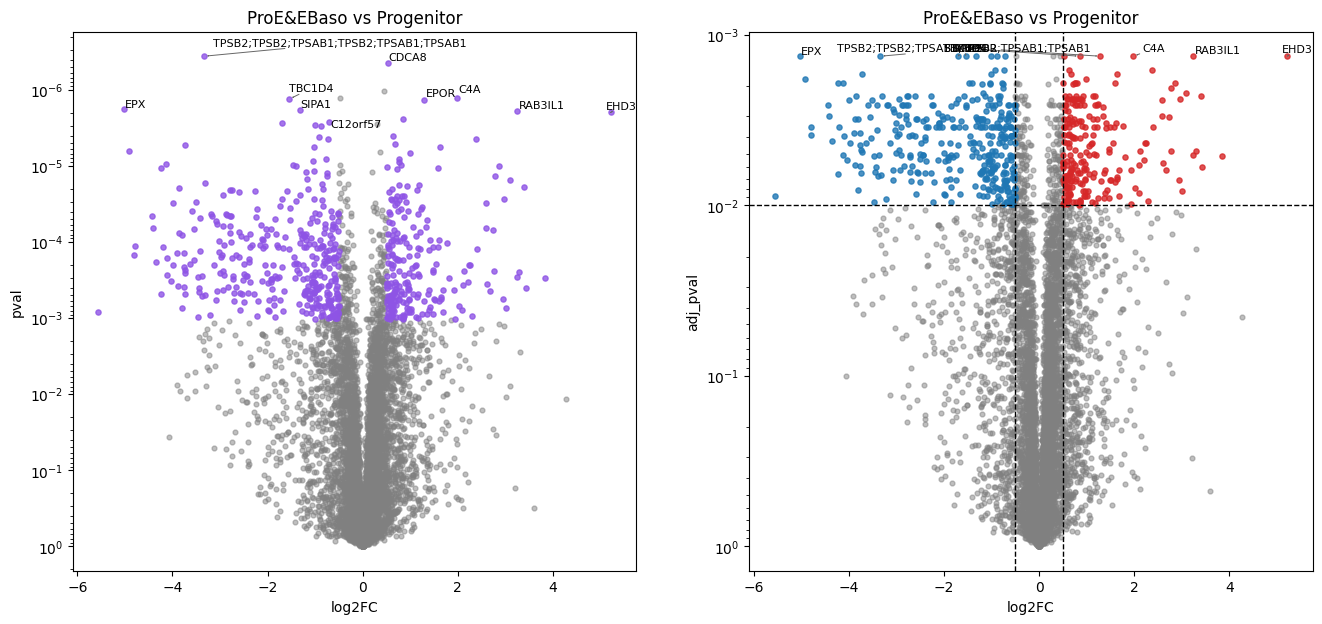

1000 (13.4%) significant differentially expressed protein groups found.


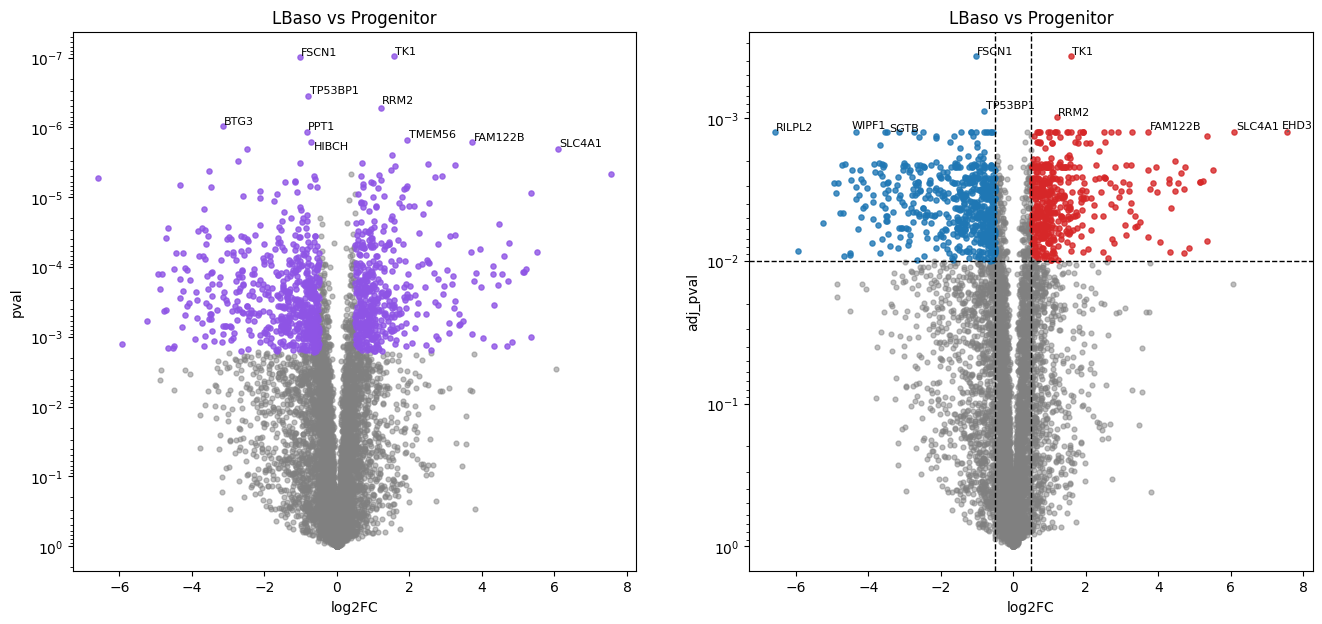

2092 (28.0%) significant differentially expressed protein groups found.


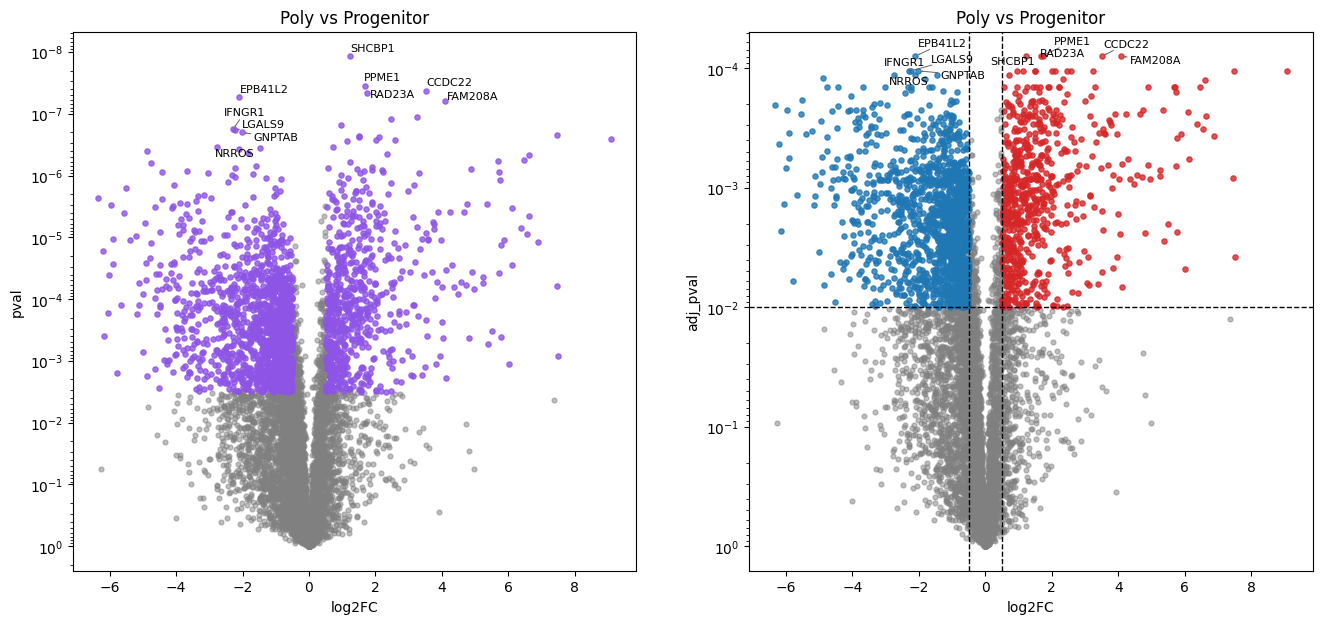

3908 (52.3%) significant differentially expressed protein groups found.


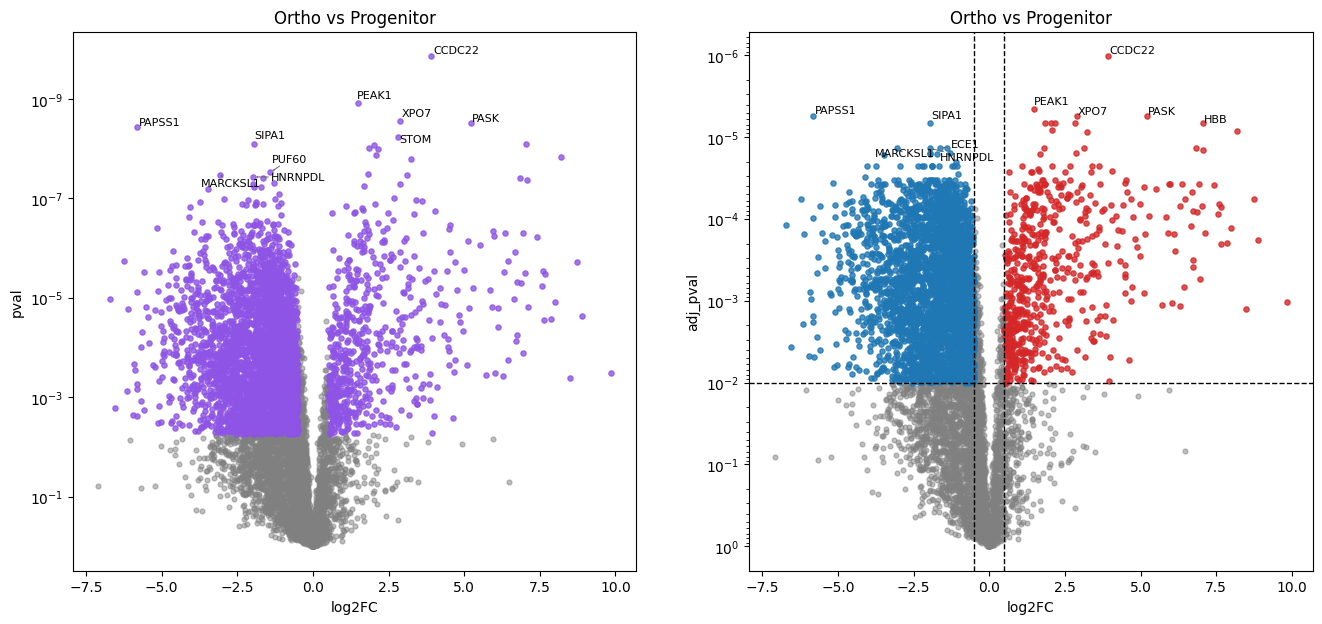

In [30]:
# Volcano plots for progenitor vs subsequent differentiation stages
for ct in rest_ct:
    test_slot = (
        f"ttest_two_sample;cell_type;"
        f"{ct.replace('&', '_')}_vs_Progenitor"
    )

    sig_df = pr.get.differential_abundance_df(
        adata, keys=test_slot,
    )
    sig_series = (
        (sig_df["pval_adj"] <= 0.01)
        & (sig_df["logfc"].abs() >= 0.5)
    )
    print(
        f"{sum(sig_series)} "
        f"({round(sum(sig_series) / adata.n_vars * 100, 1)}%) "
        f"significant differentially expressed "
        f"protein groups found."
    )

    fig, axes = plt.subplots(ncols=2, figsize=(16, 7))

    # Raw p-values, colored by adjusted significance
    pr.pl.volcano(
        adata,
        varm_slot=test_slot,
        top_labels=5,
        alt_labels_key="gene_id",
        xlabel="log2FC",
        ylabel="pval",
        pval_col="pval",
        alt_color=sig_series,
        title=f"{ct} vs Progenitor",
        ax=axes[0],
        show=False,
    )

    # Adjusted p-values
    pr.pl.volcano(
        adata,
        varm_slot=test_slot,
        fc_thresh=0.5,
        pval_thresh=0.01,
        top_labels=5,
        alt_labels_key="gene_id",
        xlabel="log2FC",
        ylabel="adj_pval",
        title=f"{ct} vs Progenitor",
        ax=axes[1],
        show=False,
    )

    plt.show()

## Summary

This notebook demonstrates a protein-level analysis workflow for DIA proteomics
data using ProteoPy. Applied to Karayel et al. (2020) the key results show:

- **Data quality**: High intra-stage reproducibility (Pearson *r* > 0.94) and 7,479 quantified proteins.
- **QC and preprocessing**: Completeness-based filtering, median normalization and downshift imputation are performed prior to downstream analysis.
- **Exploratory data analysis**: PCA resolves the five differentiation stages along the first two principal components, confirming differentiation as the dominant source of variation. UMAP embeddings support this.
- **Differential abundance**: Pairwise testing against progenitors identifies increasing numbers of differentially abundant proteins along the trajectory, with the most pronounced changes at the Poly and Ortho transition.

In [31]:
!pip freeze

adjustText==1.3.0
anndata==0.11.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.13.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.2.0
attrs==25.4.0
babel==2.18.0
beautifulsoup4==4.14.3
biopython==1.86
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
comm==0.2.3
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
et_xmlfile==2.0.0
exceptiongroup==1.3.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
h11==0.16.0
h5py==3.15.1
httpcore==1.0.9
httpx==0.28.1
idna==3.11
igraph==1.0.0
ipykernel==7.2.0
ipython==8.38.0
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.4
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
kiwisolver==1.4.